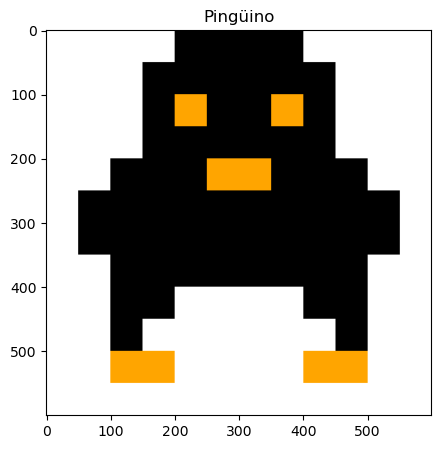

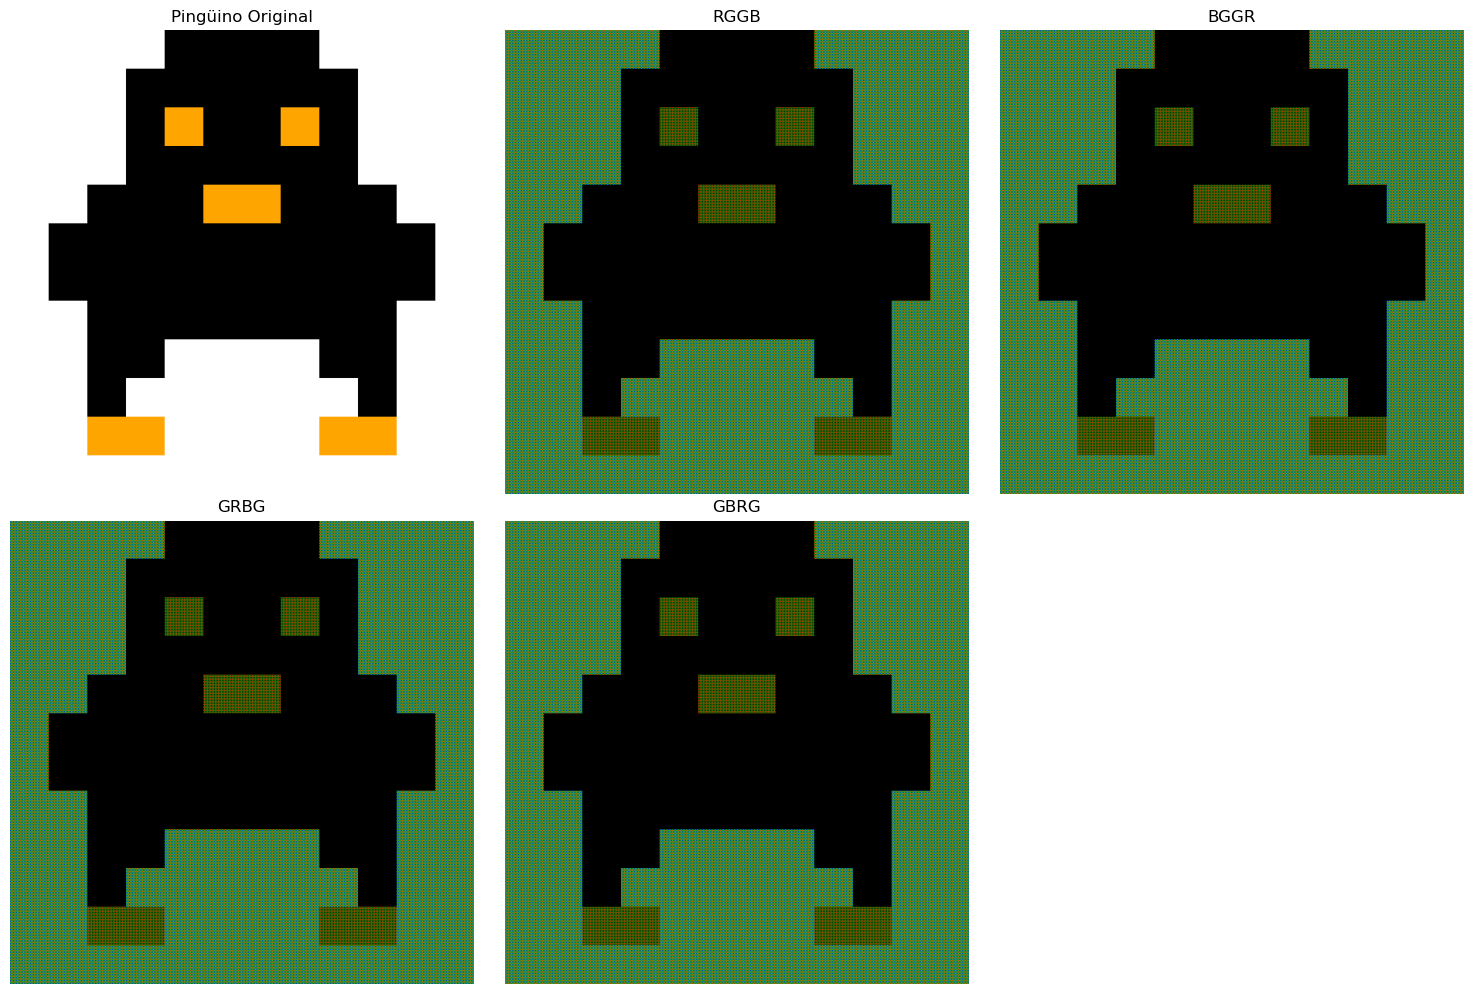

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize']=[10,5]

# Pinguino
size_cuadrante = 50
size_total = size_cuadrante * 12
imagen = np.zeros((size_total, size_total, 3), dtype=np.uint8)

# Definir colores
BLANCO = [255, 255, 255]
NEGRO = [0, 0, 0]
NARANJA = [255, 165, 0]

# Matriz del pingüino (12x12)
# 0 = blanco, 1 = negro, 2 = naranja
pinguino_matrix = [
    [0,0,0,0,1,1,1,1,0,0,0,0],
    [0,0,0,1,1,1,1,1,1,0,0,0],
    [0,0,0,1,2,1,1,2,1,0,0,0],
    [0,0,0,1,1,1,1,1,1,0,0,0],
    [0,0,1,1,1,2,2,1,1,1,0,0],
    [0,1,1,1,1,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,1,1,1,1,0],
    [0,0,1,1,1,1,1,1,1,1,0,0],
    [0,0,1,1,0,0,0,0,1,1,0,0],
    [0,0,1,0,0,0,0,0,0,1,0,0],
    [0,0,2,2,0,0,0,0,2,2,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0]
]

# Dibujar el pingüino
for i in range(12):
    for j in range(12):
        for x in range(size_cuadrante):
            for y in range(size_cuadrante):
                if pinguino_matrix[i][j] == 0:
                    # blanco
                    imagen[i*size_cuadrante + x, j*size_cuadrante + y] = BLANCO
                elif pinguino_matrix[i][j] == 1:
                    # negro
                    imagen[i*size_cuadrante + x, j*size_cuadrante + y] = NEGRO
                elif pinguino_matrix[i][j] == 2:
                    # naranja
                    imagen[i*size_cuadrante + x, j*size_cuadrante + y] = NARANJA

imagen_completa = np.array(imagen, dtype=int)

plt.figure()
plt.imshow(imagen)
plt.title('Pingüino')
plt.axis('on')
plt.savefig('pinguino_pixel_art.png')
plt.show()

# Filtros Bayer
def separar_canales(imagen):
    return imagen[:, :, 0], imagen[:, :, 1], imagen[:, :, 2]

def aplicar_bayer(rojo, verde, azul, patron):
    alto, ancho = rojo.shape
    resultado = np.zeros((alto, ancho, 3), dtype=np.uint8)
    
    if patron == "RGGB":
        resultado[0::2, 0::2, 0] = rojo[0::2, 0::2]
        resultado[0::2, 1::2, 1] = verde[0::2, 1::2]
        resultado[1::2, 0::2, 1] = verde[1::2, 0::2]
        resultado[1::2, 1::2, 2] = azul[1::2, 1::2]
    
    elif patron == "BGGR":
        resultado[0::2, 0::2, 2] = azul[0::2, 0::2]
        resultado[0::2, 1::2, 1] = verde[0::2, 1::2]
        resultado[1::2, 0::2, 1] = verde[1::2, 0::2]
        resultado[1::2, 1::2, 0] = rojo[1::2, 1::2]
    
    elif patron == "GRBG":
        resultado[0::2, 0::2, 1] = verde[0::2, 0::2]
        resultado[0::2, 1::2, 0] = rojo[0::2, 1::2]
        resultado[1::2, 0::2, 2] = azul[1::2, 0::2]
        resultado[1::2, 1::2, 1] = verde[1::2, 1::2]
    
    elif patron == "GBRG":
        resultado[0::2, 0::2, 1] = verde[0::2, 0::2]
        resultado[0::2, 1::2, 2] = azul[0::2, 1::2]
        resultado[1::2, 0::2, 0] = rojo[1::2, 0::2]
        resultado[1::2, 1::2, 1] = verde[1::2, 1::2]
    
    return resultado

# Separar canales y aplicar patrones
rojo, verde, azul = separar_canales(imagen)
patrones = ["RGGB", "BGGR", "GRBG", "GBRG"]
resultados = {}

for patron in patrones:
    resultados[patron] = aplicar_bayer(rojo, verde, azul, patron)

# Mostrar resultados
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(imagen)
axes[0,0].set_title('Pingüino Original')
axes[0,0].axis('off')

axes[0,1].imshow(resultados["RGGB"])
axes[0,1].set_title('RGGB')
axes[0,1].axis('off')

axes[0,2].imshow(resultados["BGGR"])
axes[0,2].set_title('BGGR')
axes[0,2].axis('off')

axes[1,0].imshow(resultados["GRBG"])
axes[1,0].set_title('GRBG')
axes[1,0].axis('off')

axes[1,1].imshow(resultados["GBRG"])
axes[1,1].set_title('GBRG')
axes[1,1].axis('off')

axes[1,2].axis('off')

plt.tight_layout()
plt.savefig('pinguino_bayer.png', dpi=300, bbox_inches='tight')
plt.show()